In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [4]:
(train_ds, test_ds), info = tfds.load(
    'plant_village',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)
class_names = info.features['label'].names
print("Total Classes:", len(class_names))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.QX6I7Y_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Total Classes: 38


In [5]:
def preprocess(image, label):
    image = tf.image.resize(image, [64, 64])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


In [6]:
model = keras.Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(38, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,102 (2.62 MB)

 Trainable params: 688,102 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# CELL 6 - Train the Model
history = model.fit(train_ds,
                    epochs=5,
                    validation_data=test_ds)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6920 - loss: 1.0164 - val_accuracy: 0.8027 - val_loss: 0.6441
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 29s 22ms/step - accuracy: 0.7495 - loss: 0.8109 - val_accuracy: 0.8582 - val_loss: 0.4574
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.7883 - loss: 0.6776 - val_accuracy: 0.8788 - val_loss: 0.3823
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.8138 - loss: 0.5787 - val_accuracy: 0.8699 - val_loss: 0.4051
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.8327 - loss: 0.5220 - val_accuracy: 0.8813 - val_loss: 0.3808


In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print('Test Accuracy:', test_acc)
print('Test Loss    :', test_loss)

340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8813 - loss: 0.3808
Test Accuracy: 0.8813184499740601
Test Loss    : 0.3807818591594696


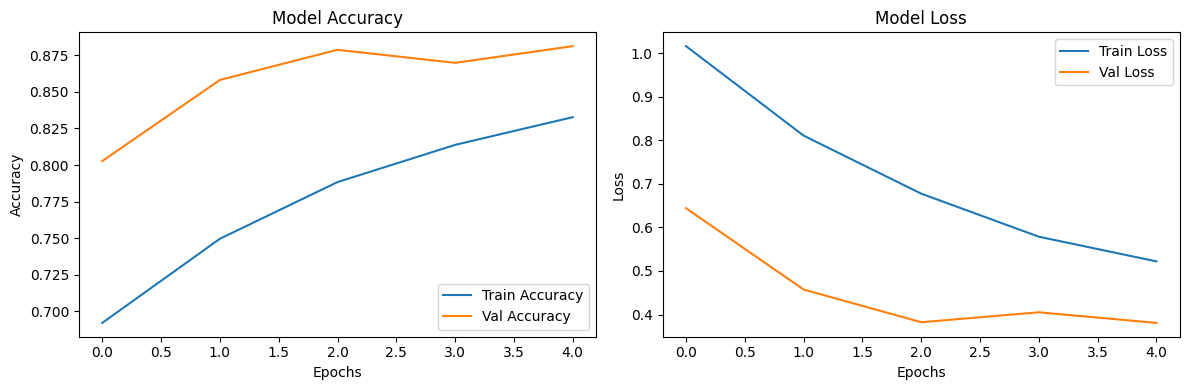

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 684ms/step


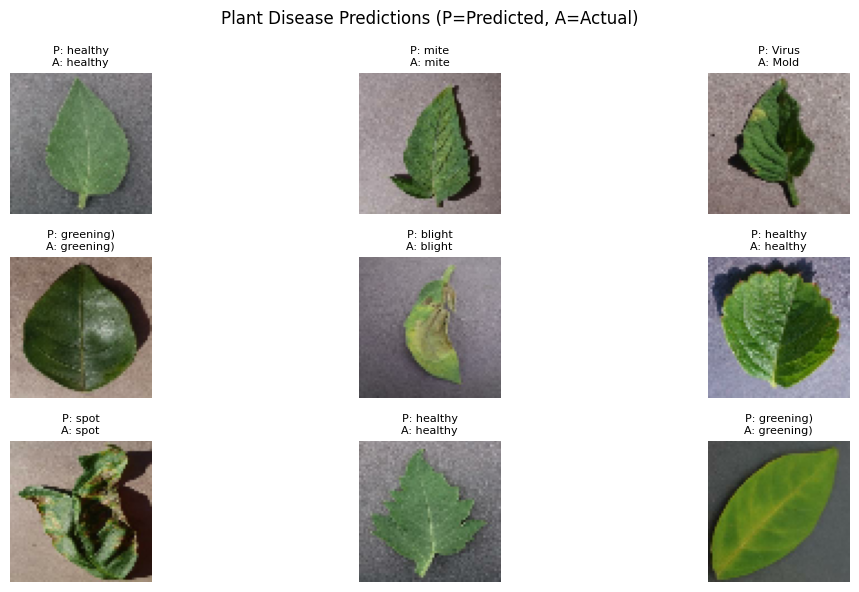

In [11]:
plt.figure(figsize=(12, 6))
for images, labels in test_ds.take(1):
    predictions    = model.predict(images[:9])
    predicted_lbls = np.argmax(predictions, axis=1)
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(f"P: {class_names[predicted_lbls[i]].split('_')[-1]}\n"
                  f"A: {class_names[labels[i]].split('_')[-1]}", fontsize=8)
        plt.axis('off')
plt.suptitle('Plant Disease Predictions (P=Predicted, A=Actual)')
plt.tight_layout()
plt.show()